In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.integrate import quad
from scipy import optimize
import pickle
from IPython.display import Image
from plotly.offline import plot

# Seed and random generator
np.random.seed(123456)
from numpy.random import Generator, PCG64
rng = Generator(PCG64())

# Fixed tolerance for comparisons
EPSILON: float = 1e-8

# Implemented classes
from simulator import EulerMaruyama, Milstein, RungeKutta
from utils import plot_simulation, plot_white_shot, pdf


In [2]:
# Model Parameters
r0 = 2.0
p = 0.5
k = 1.5
h = 1.2
beta = 0.5
theta = 0.6
alpha = 0.24
m = 0.34

# Noise parameters
sigma = np.array([
    [1e-2, 1e-2],
    [1e-2, 1e-2]
])
sigma *= 5

# Drift function
def f(x, t):
    u, v = x
    f_u = ((r0*u) / (1 + k*alpha*v)) - beta*(u**2) - (((p + alpha*v)*u*v) / (1 + h*(p + alpha*v)*u))
    f_v = ((theta*(p + alpha*v)*u*v) / (1 + h*(p + alpha*v)*u)) - m*v
    return np.array([f_u, f_v])

# Diffusion function
def g(x, t):
    u, v = x
    g_u = u*(sigma[0,0] + sigma[0, 1]*u)
    g_v = v*(sigma[1,0] + sigma[1, 1]*v)
    return np.array([g_u, g_v])

# First derivatives of diffusion function
def dg(x, t):
    u, v = x
    dg_u = sigma[0, 0] + 2*sigma[0, 1]*u
    dg_v = sigma[1, 0] + 2*sigma[1, 1]*v
    return np.array([dg_u, dg_v])


In [3]:
# Simulation variables
x0 = np.array([3.6, 2.4])   # Initial [prey, predator] densities
T = 100

# Set a high N to compute a reference solution
N = 1_000_000

# Generate a unique noise vector for all 3 algorithms
dW = rng.normal(loc=0.0, scale=np.sqrt(T/N), size=(N, 2)) # 2: dimension of state space

# Initialize the simulators
x0 = np.array([3.6, 2.4])   # Initial [prey, predator] densities

# Compute reference solution
reference = Milstein(x0, T, N, f, g, dg)
x_ref, t_ref = reference.simulate_dW(dW)

In [4]:
# euler = EulerMaruyama(x0, T, N, f, g)
# milstein = Milstein(x0, T, N, f, g, dg)
# runge = RungeKutta(x0, T, N, f, g)

# # Simulate with the 3 algorithms
# x_e, t_e = euler.simulate_dW(dW)
# x_m, t_m = milstein.simulate_dW(dW)
# x_r, t_r = runge.simulate_dW(dW)

# ----------

# For different dt values, compute the L2 error wrt the reference solution
N_values = [110, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000]

errors_euler = []
errors_milstein = []
errors_runge = []

x0 = np.array([3.6, 2.4])   # Initial [prey, predator] densities

for i, N in enumerate(N_values, start=1):
    
    print(f"Simulating for N={N} ({i}/{len(N_values)})")
    
    # Generate a unique noise vector for all 3 algorithms
    dW = rng.normal(loc=0.0, scale=np.sqrt(T/N), size=(N, 2)) # 2: dimension of state space
    
    # Initialize the simulators
    euler = EulerMaruyama(x0, T, N, f, g)
    milstein = Milstein(x0, T, N, f, g, dg)
    runge = RungeKutta(x0, T, N, f, g)
    
    # Simulate with the 3 algorithms
    x_e, t_e = euler.simulate_dW(dW)
    x_m, t_m = milstein.simulate_dW(dW)
    x_r, t_r = runge.simulate_dW(dW)
    
    # Interpolate the reference solution at the time points of the current simulation
    x_ref_interp = np.zeros_like(x_e)
    x_ref_interp[:, 0] = np.interp(t_e, t_ref, x_ref[:, 0])
    x_ref_interp[:, 1] = np.interp(t_e, t_ref, x_ref[:, 1])
    
    # Compute the L2 error for both prey and predator densities
    error_euler = np.sqrt(np.mean((x_e - x_ref_interp)**2))
    error_milstein = np.sqrt(np.mean((x_m - x_ref_interp)**2))
    error_runge = np.sqrt(np.mean((x_r - x_ref_interp)**2))
    
    errors_euler.append(error_euler)
    errors_milstein.append(error_milstein)
    errors_runge.append(error_runge)
   

Simulating for N=110 (1/8)
Simulating for N=500 (2/8)
Simulating for N=1000 (3/8)
Simulating for N=5000 (4/8)
Simulating for N=10000 (5/8)
Simulating for N=50000 (6/8)
Simulating for N=100000 (7/8)
Simulating for N=500000 (8/8)


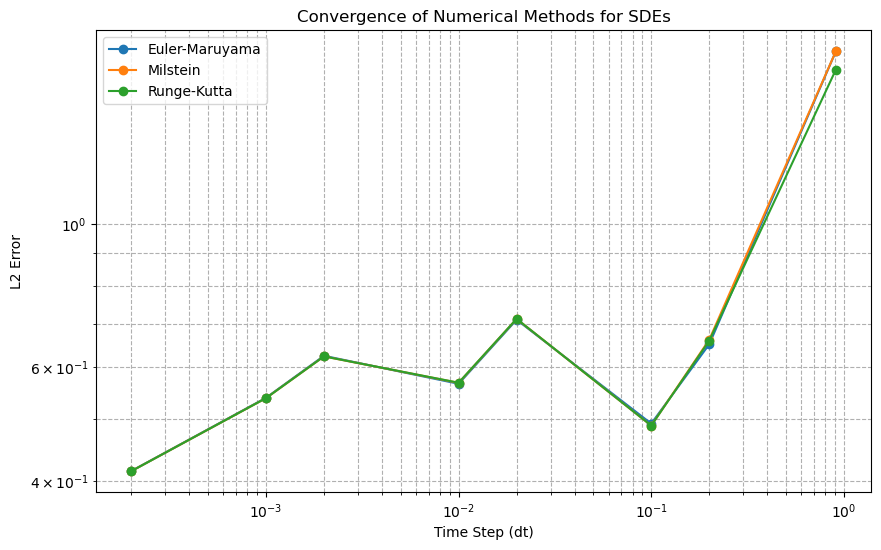

In [5]:
# Plot errors vs dt=T/N on a log-log scale
dt_values = [T/N for N in N_values]
plt.figure(figsize=(10, 6))
plt.loglog(dt_values, errors_euler, marker='o', label='Euler-Maruyama')
plt.loglog(dt_values, errors_milstein, marker='o', label='Milstein')
plt.loglog(dt_values, errors_runge, marker='o', label='Runge-Kutta')
plt.xlabel('Time Step (dt)')
plt.ylabel('L2 Error')
plt.title('Convergence of Numerical Methods for SDEs')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show() 

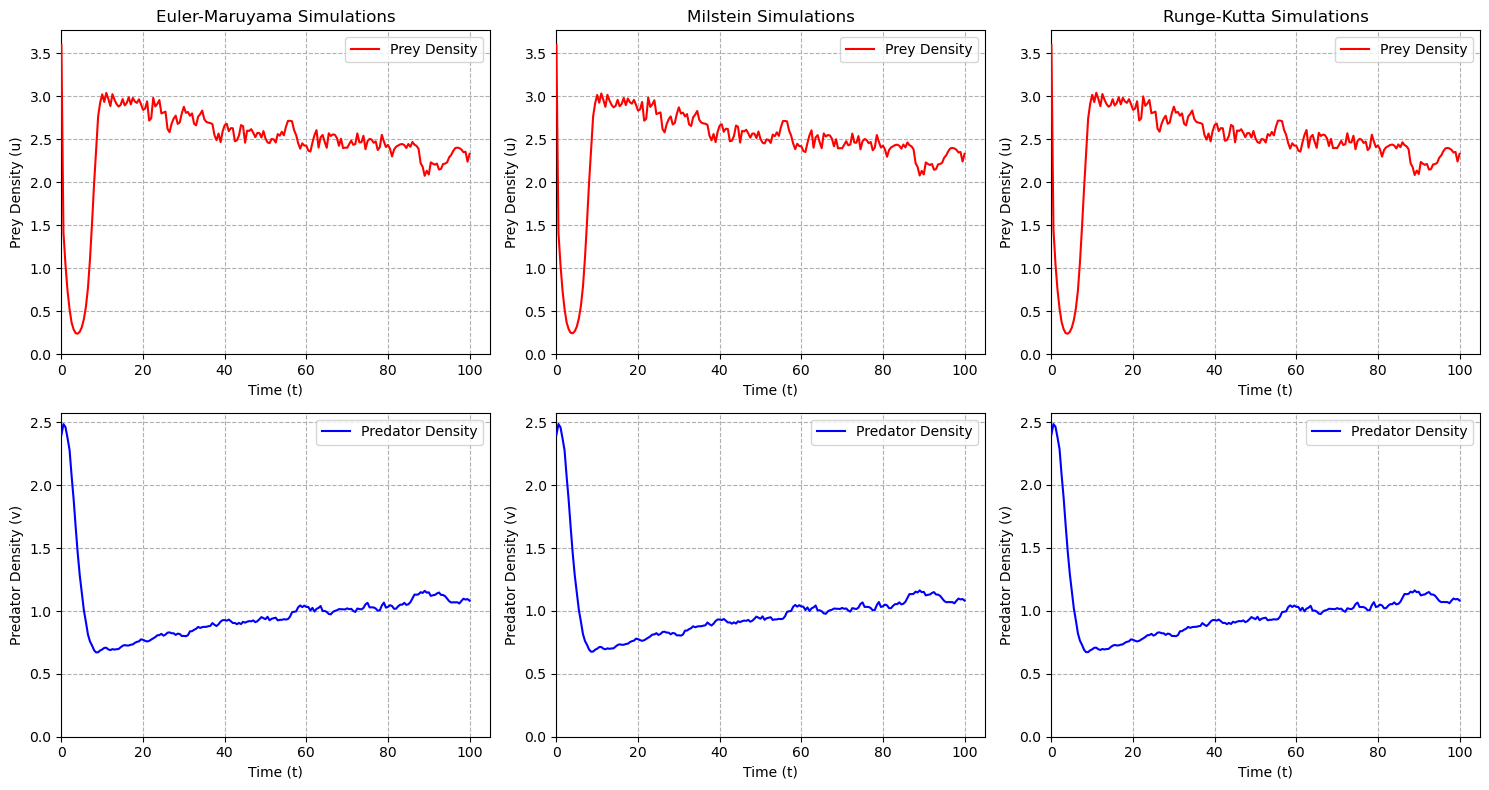

In [ ]:
# # Compare the results
# fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# # Euler-Maruyama (1st colmn)
# ax[0,0].plot(t_e, x_e[:, 0], label='Prey Density', color='red', zorder=3)
# ax[0,0].set_title('Euler-Maruyama Simulations')
# ax[0,0].set_xlabel('Time (t)')
# ax[0,0].set_ylabel('Prey Density (u)')
# ax[0,0].set_xlim(0, None)
# ax[0,0].set_ylim(0, None)
# ax[0,0].grid(linestyle='--', zorder=1)
# ax[0,0].legend()


# ax[1,0].plot(t_e, x_e[:, 1], label='Predator Density', color='blue', zorder=3)
# ax[1,0].set_xlabel('Time (t)')
# ax[1,0].set_ylabel('Predator Density (v)')
# ax[1,0].set_xlim(0, None)
# ax[1,0].set_ylim(0, None)
# ax[1,0].grid(linestyle='--', zorder=1)
# ax[1,0].legend()

# # Milstein (2nd column)
# ax[0,1].plot(t_m, x_m[:, 0], label='Prey Density', color='red', zorder=3)
# ax[0,1].set_title('Milstein Simulations')
# ax[0,1].set_xlabel('Time (t)')
# ax[0,1].set_ylabel('Prey Density (u)')
# ax[0,1].set_xlim(0, None)
# ax[0,1].set_ylim(0, None)
# ax[0,1].grid(linestyle='--', zorder=1)
# ax[0,1].legend()

# ax[1,1].plot(t_m, x_m[:, 1], label='Predator Density', color='blue', zorder=3)
# ax[1,1].set_xlabel('Time (t)')
# ax[1,1].set_ylabel('Predator Density (v)')
# ax[1,1].set_xlim(0, None)
# ax[1,1].set_ylim(0, None)
# ax[1,1].grid(linestyle='--', zorder=1)
# ax[1,1].legend()

# # Runge-Kutta (3rd column)
# ax[0,2].plot(t_r, x_r[:, 0], label='Prey Density', color='red', zorder=3)
# ax[0,2].set_title('Runge-Kutta Simulations')
# ax[0,2].set_xlabel('Time (t)')
# ax[0,2].set_ylabel('Prey Density (u)')
# ax[0,2].set_xlim(0, None)
# ax[0,2].set_ylim(0, None)
# ax[0,2].grid(linestyle='--', zorder=1)
# ax[0,2].legend()

# ax[1,2].plot(t_r, x_r[:, 1], label='Predator Density', color='blue', zorder=3)
# ax[1,2].set_xlabel('Time (t)')
# ax[1,2].set_ylabel('Predator Density (v)')
# ax[1,2].set_xlim(0, None)
# ax[1,2].set_ylim(0, None)
# ax[1,2].grid(linestyle='--', zorder=1)
# ax[1,2].legend()

# plt.tight_layout()
# plt.show()

# # NAME = 'algorithms_comparison'
# # plt.savefig(f'../docs/images/{NAME}.png', format='png', dpi=300)
# # plt.close()
# # display(Image(filename=f"../docs/images/{NAME}.png"))


In [6]:
# Skeleton of error coomparison code to implement
import numpy as np
from math import sqrt
from sklearn.linear_model import LinearRegression   # or np.polyfit
from tqdm.notebook import tqdm

rng = np.random.default_rng(12345)

def simulate_method_on_path(method, x0, T, N, f, g, dg=None, dW=None):
    # method is 'EM', 'Milstein' or 'SRK' ; dW should be shape (N, dim)
    dt = T / N
    x = x0.copy().astype(float)
    for n in range(N):
        xi = dW[n] / sqrt(dt)   # normalized N(0,1) if dW given as sqrt(dt)*xi
        if method == 'EM':
            x = x + f(x, n*dt)*dt + g(x, n*dt) * dW[n]
        elif method == 'Milstein':
            # scalar/vector diagonal assumed; use componentwise formula
            gval = g(x, n*dt)
            dgval = dg(x, n*dt)
            corr = 0.5 * gval * dgval * (dW[n]**2 - dt)
            x = x + f(x, n*dt)*dt + gval * dW[n] + corr
        elif method == 'SRK':
            x_hat = x + f(x, n*dt) * dt + g(x, n*dt) * np.sqrt(dt)
            x = (
                x + 
                f(x, n*dt) * dt +
                g(x, n*dt) * dW[n] +
                0.5 * (g(x_hat, n*dt) - g(x, n*dt)) * (dW[n]**2 - dt) / np.sqrt(dt)
            )

    return x

# strong convergence experiment
T = 1.0
x0 = np.array([2.3075, 1.1143])
dims = 2
seeds = 200      # number of independent Brownian paths to average over
dt_exponents = np.arange(3, 15)  # dt = 2^{-k} -> coarsest to finer
errors = {'EM':[], 'Milstein':[], 'SRK':[]}

for k in tqdm(dt_exponents):
    N = 2**k
    dt = T / N
    # Create fine reference increments: choose fine_N = N_ref = N * 32 (for reference)
    refine_factor = 32
    Nref = N * refine_factor
    dt_ref = T / Nref
    # Generate reference fine gaussian increments for each seed, nested so each method uses same coarse path
    rms_errors = {'EM':[], 'Milstein':[], 'SRK':[]}
    for s in range(seeds):
        dW_ref = rng.normal(0.0, sqrt(dt_ref), size=(Nref, dims))
        # build coarse dW by summing blocks of 16 fine increments -> ensures nested increments
        dW_coarse = dW_ref.reshape(N, refine_factor, dims).sum(axis=1)
        # reference path: use Milstein with Nref steps
        x_ref = simulate_method_on_path('Milstein', x0, T, Nref, f, g, dg, dW=dW_ref)
        for method in ['EM','Milstein','SRK']:
            x_num = simulate_method_on_path(method, x0, T, N, f, g, dg, dW=dW_coarse)
            err = np.linalg.norm(x_num - x_ref)   # Euclidean error at T
            rms_errors[method].append(err)
    # average RMS
    for method in errors:
        errors[method].append(np.sqrt(np.mean(np.array(rms_errors[method])**2)))


  0%|          | 0/12 [00:00<?, ?it/s]

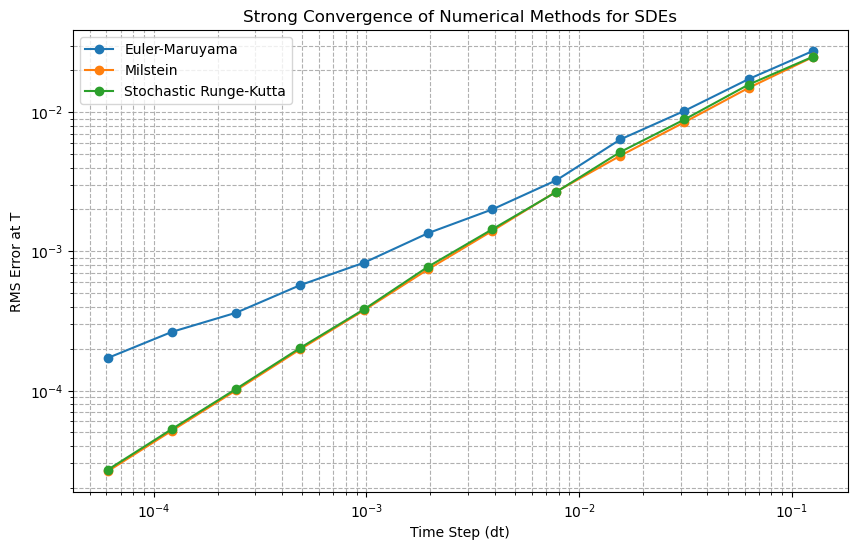

In [7]:
# Now plot log(errors) vs log(dt) and fit slopes
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
dt_values = [T/(2**k) for k in dt_exponents]
plt.loglog(dt_values, errors['EM'], marker='o', label='Euler-Maruyama')
plt.loglog(dt_values, errors['Milstein'], marker='o', label='Milstein')
plt.loglog(dt_values, errors['SRK'], marker='o', label='Stochastic Runge-Kutta')
plt.xlabel('Time Step (dt)')
plt.ylabel('RMS Error at T')
plt.title('Strong Convergence of Numerical Methods for SDEs')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

In [9]:
# Store the results with pickle
import pickle
with open('convergence_results.pkl', 'wb') as f:
    pickle.dump((dt_values, errors), f)

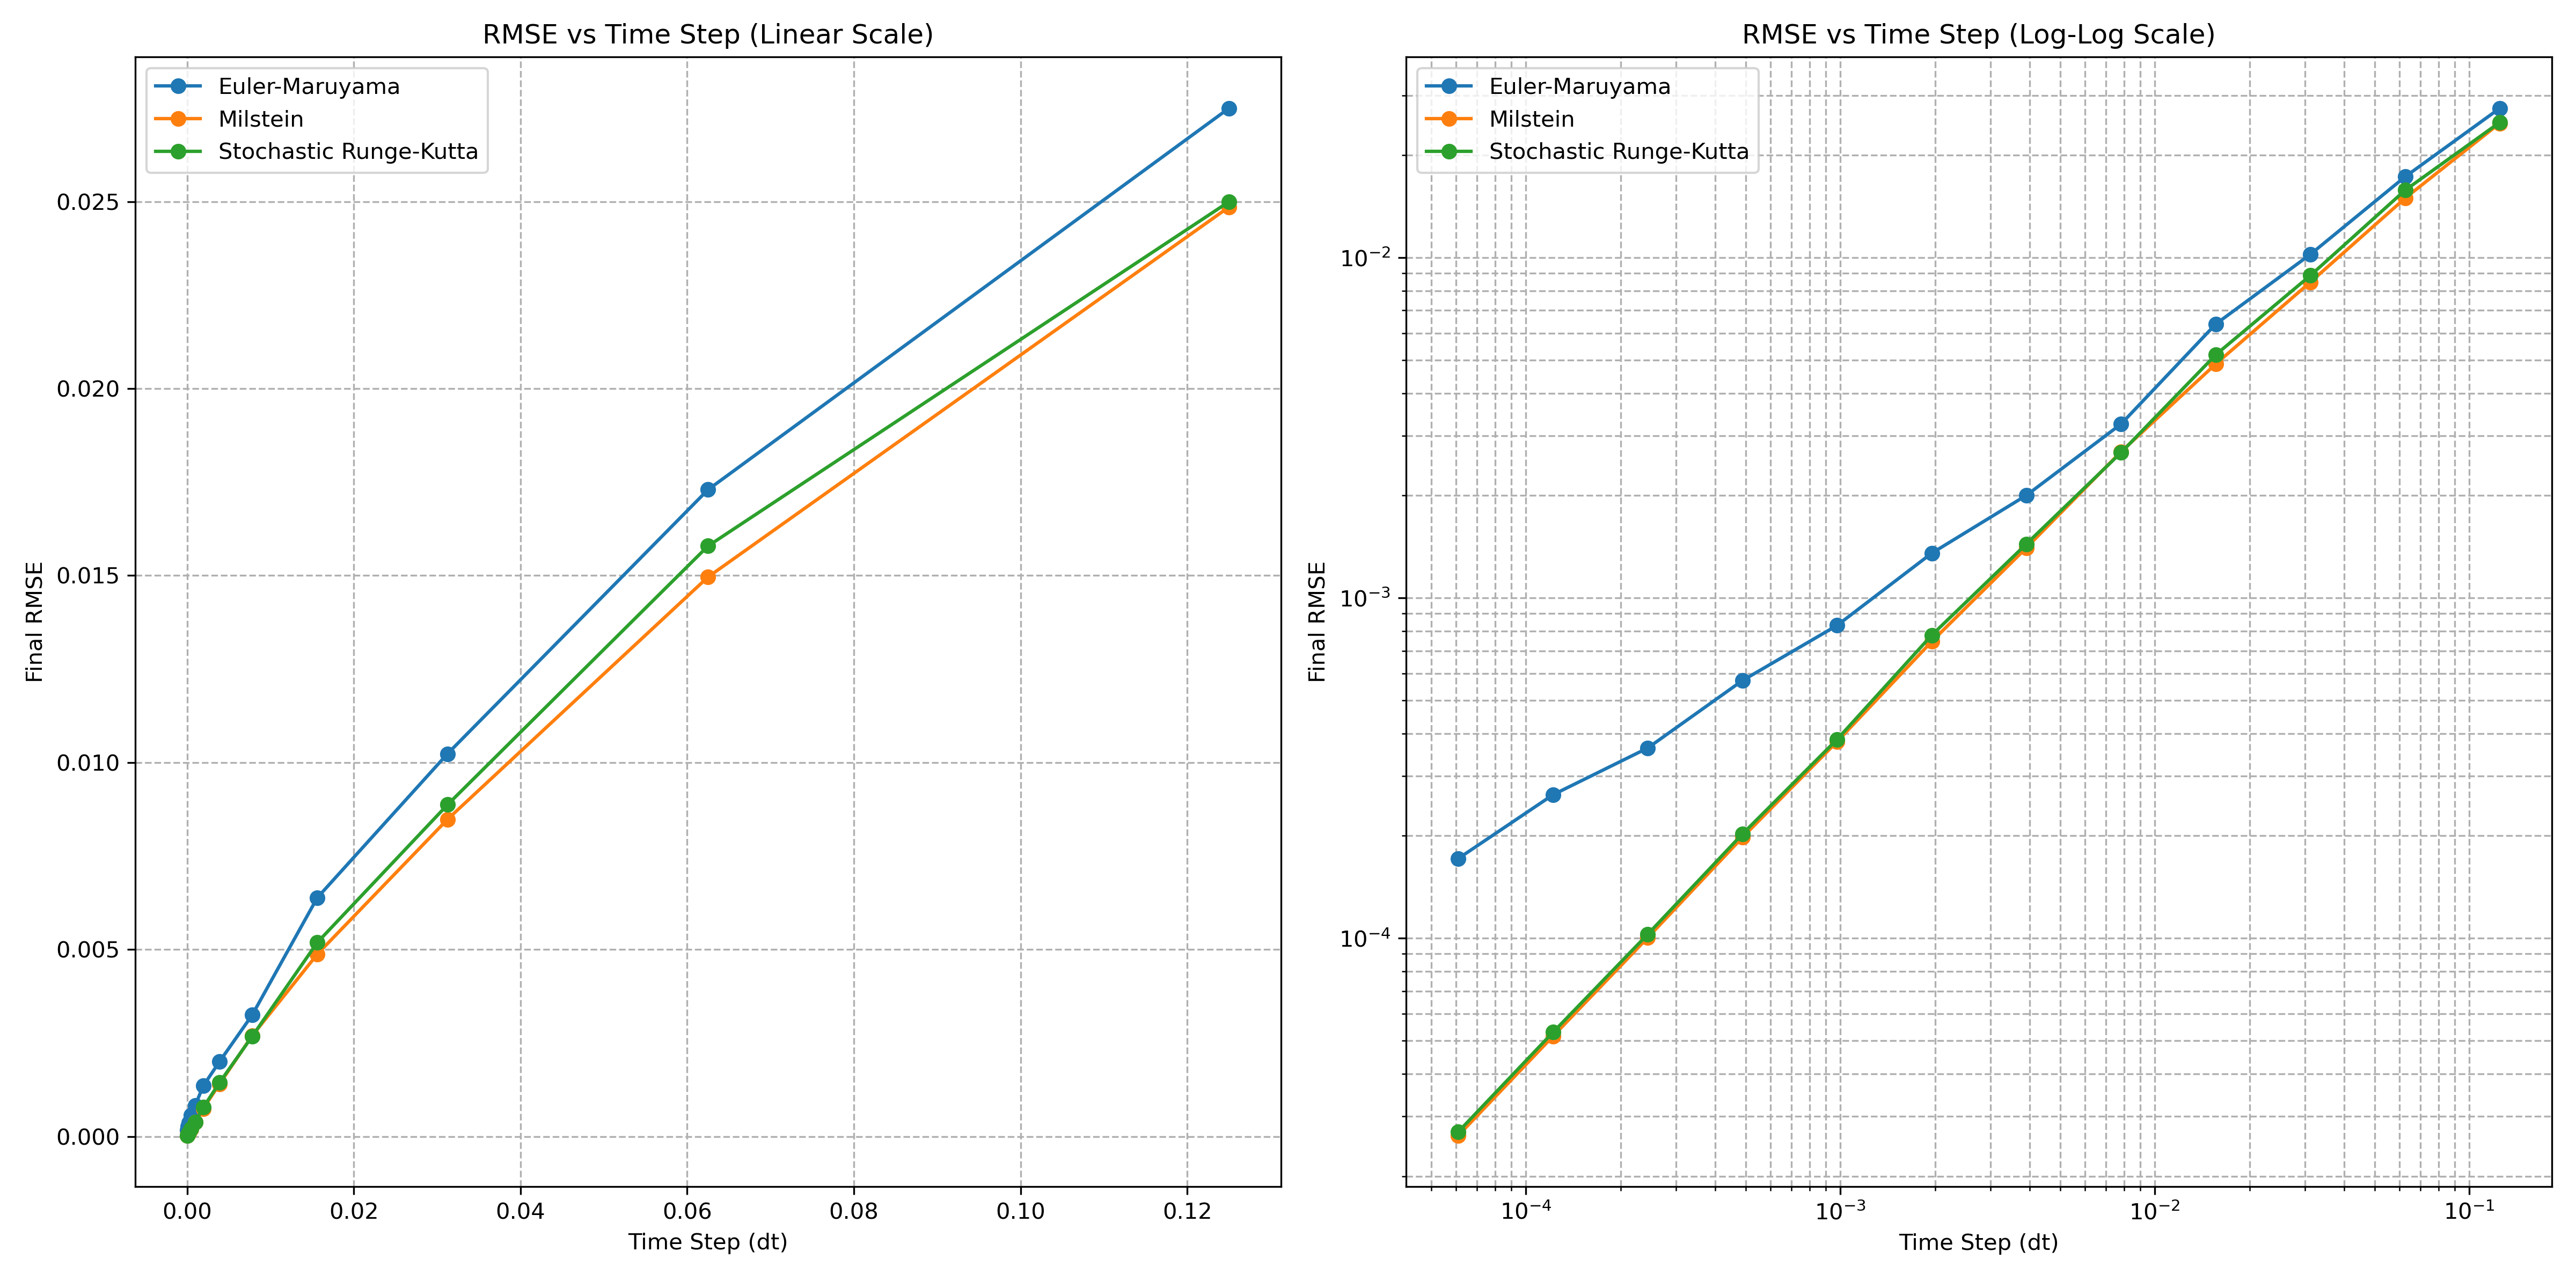

In [15]:
# Side by side plot of errors in normal scale and then in logarithmic scale

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Linear scale plot
ax[0].plot(dt_values, errors['EM'], marker='o', label='Euler-Maruyama')
ax[0].plot(dt_values, errors['Milstein'], marker='o', label='Milstein')
ax[0].plot(dt_values, errors['SRK'], marker='o', label='Stochastic Runge-Kutta')
ax[0].set_xlabel('Time Step (dt)')
ax[0].set_ylabel('Final RMSE')
ax[0].set_title('RMSE vs Time Step (Linear Scale)')
ax[0].legend()
ax[0].grid(True, which="both", ls="--")
ax[0].set_xscale('linear')
ax[0].set_yscale('linear')
# ax[0].invert_xaxis()  # Invert x-axis to show smaller dt on the right

# Logarithmic scale plot
ax[1].loglog(dt_values, errors['EM'], marker='o', label='Euler-Maruyama')
ax[1].loglog(dt_values, errors['Milstein'], marker='o', label='Milstein')
ax[1].loglog(dt_values, errors['SRK'], marker='o', label='Stochastic Runge-Kutta')
ax[1].set_xlabel('Time Step (dt)')
ax[1].set_ylabel('Final RMSE')
ax[1].set_title('RMSE vs Time Step (Log-Log Scale)')
ax[1].legend()
ax[1].grid(True, which="both", ls="--")
# ax[1].invert_xaxis()  # Invert x-axis to show smaller dt on the right

plt.tight_layout()
# plt.show()

NAME = 'convergence'
plt.savefig(f'../docs/images/{NAME}.png', format='png', dpi=300)
plt.close()
display(Image(filename=f"../docs/images/{NAME}.png"))

In [16]:
# Fit the log-log data to find slopes
log_dt = np.log(dt_values).reshape(-1, 1)
for method in errors:
    log_err = np.log(errors[method])
    reg = LinearRegression().fit(log_dt, log_err)
    slope = reg.coef_[0]
    intercept = reg.intercept_
    print(f"{method}: slope = {slope:.2f}, intercept = {intercept:.2f}")

EM: slope = 0.67, intercept = -2.30
Milstein: slope = 0.91, intercept = -1.63
SRK: slope = 0.91, intercept = -1.59
